# Interim Daily Primary Productivity (NetPP) Algorithm
> History | Updated Dec 2024

## Background

**Net primary productivity in the ocean is the rate at which phytoplankton store energy as biomass and make it available to other consumers in an ecosystem.**

* It is typically reported in units like mg C/m2/day

* It is driven by photosynthesis where phytoplankton use light energy to convert $\text{CO}_2$ into organic carbon.

**Productivity measurements happen in the field, usually on a research cruise.**

* Water is collected at several depths in the water column.

* The water is spiked with radiolabeled C ($C^{14}$), and incubated over a range of light levels for 24 hours.

* The rate of radiolabeled C ending up in pythoplankton cells is used to determine net primary productivity.

**The 1997 Behrenfeld and Falkowski algorithm estimates primary productivity using satellite measurements.**

* The algorithm uses three satellite measurements:

    * chlorophyll_a (Chl) https://en.wikipedia.org/wiki/Chlorophyll_a

    * sea surface temperature (SST)

    * photosynthetically active radiation (PAR) https://en.wikipedia.org/wiki/Photosynthetically_active_radiation

* The type of model is called a Vertically Generalized Production Model (VGPM). https://en.wikipedia.org/wiki/Vertically_Generalized_Production_Model

### **The algorithm formulation is listed below:**

> $PP_{eu} = 0.66125 \times P_{opt}^b \times \frac{PAR^o}{PAR^o + 4.1} \times Z_{eu} \times CHL \times DL$
>
> ### Where:

* CHL = chlorophyll a concentration at surface (mg m^-3)
* DL = Daylight hours - (hours)
* $Z_{eu}$ = the depth where light is 1% of that at the surface - Units: meters (m)
* $P_{opt}^b$ Maximum C fixation rate within the water column - Units: mg C (mg Chl)-1 h-1
* PAR = Photosynthetically Active Radiation - Units: Daily average insitu par (Einstein m-2 d-1)

### Several of these parameters can be determined with satellite data

$P_{opt}^b$ is derived from SST using the seventh order polynomial of Behrenfeld and Falkowski (1997).

> $P_{opt}^b = -3.27E-8 \cdot T^7 + 3.4132E-6 \cdot T^6 - 1.348E-4 \cdot T^5 + 2.462E-3 \cdot T^4 - 0.0205 \cdot T^3 + 0.0617 \cdot T^2 + 0.2749 \cdot T$

* Where T = temperature in Celsius (℃)


$Z_{eu}$ is derived from an estimate of the total chlorophyll concentration within the euphotic layer ($CHL_{eu}$) based on the Case I models of Morel and Berthon (1989):

> $Z_{eu} = 568.2 \cdot CHL^{-0.746} \quad \text{when } CHL_{eu} > 10.0$
>
> or
>
> $Z_{eu} = 200.0 \cdot CHL^{-0.293} \quad \text{when } CHL_{eu} \leq 10.0$

> Where:
>
> - $CHL_{eu} = 38.0 \cdot CHL^{0.4250} \quad \text{when } CHL \leq 1.0$
> - or
> - $CHL_{eu} = 40.2 \cdot CHL^{0.5070} \quad \text{when } CHL > 1.0$

## Objective

Create primary productivity satellite-based products.

This script generates primary productivity fields from chlorophyll, SST, PAR
satellite data using the method of Behrenfeld and Falkowski 1997. It accepts
source satellite data that has been gridded to the NASA 4Km SMI.
NOAA CoastWatch standard ocean color grid. As written, the script is tailored
for pairing the following global, daily input data to produce
primary productivity fields:

* **NASA NOAA20-VIIRS chlorophyll and PAR**
* **NASA NOAA21-VIIRS chlorophyll and PAR**
* **SST from the NOAA Gridded Super-collated product**

Users set the satellite input data, start dates and stop date
via command-line arguments.

The output files are created by generating a template netCDF file from a cdl
file that is prepopulated with metadata but has only latitude and longitude
data. The template file is populated with the primary productivity data
and then renamed.

The script can be repurposed for different input data with these modifications:

* Gridding any input chlorophyll, PAR, and SST data to a common grid.

* Creating an appropriate cdl file for the dataset.

* Adjusting the logic to make directory paths.

* Adjust output file naming and input file search pattern.

> ### **Steps:**
>
> **Directory Setup**
>
> * Ensure all required directories are created dynamically based on the input parameters.
>
> **Download Data**
>
> * Download CHL, PAR, and SST data.
>
> * Regrid SST to match NASA's 4km grid using CoastWatch Utilities.
>
> **NetPP Calculations**
>
> * Load datasets (CHL, PAR, SST).
>
> * Calculate:
>   * $P_{opt}^b$ : Chlorophyll-specific productivity.
>
>   * $Z_{eu}$ : Euphotic depth.
>
>   * DL: Daylength.
>      
>   * NetPP using the Behrenfeld-Falkowski algorithm.
>
> **Save NetPP Output**
>
> * Generate a NetCDF file for each date, populated with calculated fields and metadata.
>
> * Compress the NetCDF file and move it to the target directory.
>
> **Send the data to ERDDAP**
>
> * Transfer the locally generated NetCDF files to a remote ERDDAP server's monitored data directory.
>
> **Visualize the NetPP data**
> 
> * Create global plots of NetPP, SST, CHL, & PAR
>
> * Plot $P_{opt}^b$ as a function of SST

### Resource Requirements

* Jupyter Notebook.

* Python 3 with the modules included within the "Import packages" section below.

* Template CDL file that is prepopulated with metadata but has only latitude and longitude data. Can be found here:

* Internet connection.

* NASA Earth Data Credentials?

## Import packages

In [1]:
import matplotlib.pyplot as plt

%matplotlib inline
import numpy.ma as ma
import numpy as np
import os
import subprocess
import pandas as pd
from netCDF4 import Dataset
from datetime import timedelta, datetime, timezone
import sys
from dateutil.parser import parse
import warnings

warnings.filterwarnings("ignore")

## Create global variables

Global variables are used to set up the file structure, directory paths, and template files required for processing NetPP.

In [2]:
ROOT_DIR = "/Users/madisonrichardson/netpp"
CHL_DIR_T = os.path.join(ROOT_DIR, "data/{}/chl/daily_chl")
PAR_DIR_T = os.path.join(ROOT_DIR, "data/{}/par/daily_chl")
SST_2k_DIR_T = os.path.join(ROOT_DIR, "data/{}/sst_2k")
WORK_DIR = os.path.join(ROOT_DIR, "work")
BIN_DIR = os.path.join(ROOT_DIR, "bin")
RES_DIR = os.path.join(ROOT_DIR, "resources")
NC_OUT_DIR_T = os.path.join(ROOT_DIR, "data/{}/netpp/daily_netpp")
CWUTL_DIR = '"/Applications/CoastWatch Utilities/bin"'
CWUTIL_OFILE_HDF = "nasa_4k.hdf"
CWUTIL_OFILE_NC = "nasa_4k.nc"
MASTER_FILE = "netpp_master.nc"
# Add the ncgen input cdl and output nc file names
CDL_IN_FILE = "June32023_dhr.cdl"
TEMP_OUT_FILE = "temp_ofile.nc"

## Create useful functions

### Generates the download URL for SST files based on the date.

In [3]:
def generate_url_batch(date_obj):
    """Create a URL for downloading a data file.

    Creates a URL for downloading a data file from
    NOAA ACSPO Daily Global 0.02 degree ridded Super-collated SST
    data on a specific date.

    Args_:
        date_obj (datetime): A datetime object representing the specified date
                            for which the SST (sea surface temperature) data
                            URL is generated.

    Returns_:
        tuple: A tuple containing:
            - url (str): The complete URL to download the specified data file.
            - file_name (str): The name of the data file to be downloaded.
    """
    year = "{0:%Y}".format(date_obj)
    doy = "{0:%j}".format(date_obj)

    date_str = "{0:%Y%m%d}".format(date_obj)

    base_url = (
        "https://coastwatch.noaa.gov/erddap/files/"
        "noaacwLEOACSPOSSTL3SKDaily/"
    )

    file_name = (
        f"{date_str}120000-STAR-L3S_GHRSST-SSTsubskin-"
        "LEO_Daily-ACSPO_V2.81-v02.0-fv01.0.nc"
    )

    url = f"{base_url}{year}/{doy}/{file_name}"

    return url, file_name

### Downloads SST files to the specified directory

In [4]:
def download_sst_file(url, SST_2k_DIR):
    """Download a file using generate_url_batch output.

    Downloads a file from the specified URL that is generated from
    generate_url_batch function and saves it to the specified
    directory.

    Args_:
        url (str): The URL of the file to be downloaded.
        SST_2k_DIR (str): The directory where the downloaded
        file will be saved.

    """
    command = f"wget -P {SST_2k_DIR} {url}"

    subprocess.call(command, shell=True)

    print(f"Downloaded: {url} to {SST_2k_DIR}")

### Downloads chlorophyll or PAR data from NASA for the specified date and sensor

In [5]:
def download_nasa_data(current_date, data_type, directory, sensor):
    """Download NASA data files for specified sensor.

    Downloads chlorophyll and PAR data from
    L3 NOAA20-VIIRS on NASA data search website.

    Args_:
        current_date (datetime): The date format %Y-%m-%d for which the data is
                                downloaded.
        data_type (str): The type of data to download, either
                        'chlorophyll' or 'par'.
        directory (str): The directory where the downloaded data will be saved.
        sensor (str): The sensor to use for downloading data, either 'noaa20'
                    or 'noaa21'.

    Raises_:
        ValueError: If the 'data_type is not 'chlorophyll' or 'par'.
    """
    # Validate data type
    if data_type == "chlorophyll":
        prod_id = "chlor_a"
        product_prefix = "CHL"
    elif data_type == "par":
        prod_id = "par"
        product_prefix = "PAR"
    else:
        raise ValueError("data_type must be 'chlorophyll' or 'par'")

    # Extract the start date for noaa20
    sdate = current_date.strftime("%Y-%m-%d 00:00:00")
    edate = current_date.strftime("%Y-%m-%d 23:59:59")

    if sensor == "noaa20":
        dtid = "1197"
        wget_template = " ".join(
            [
                "wget",
                "-q",
                '--post-data="results_as_file=1&sensor_id=33&dtid={}'
                "&sdate={}&edate={}",
                '&&addurl=1&prod_id={}&resolution_id=4km&period=DAY"',
                "-O {} -",
                "https://oceandata.sci.gsfc.nasa.gov/api/file_search",
            ]
        )

        file_list_name = (
            f"{data_type}_nasa_file_list_" f'{current_date.strftime("%Y%m%d")}.txt'
        )
        file_list_path = os.path.join(directory, file_list_name)

        chl_wget = wget_template.format(dtid, sdate, edate, prod_id, file_list_path)
        subprocess.call(chl_wget, shell=True)

        df = pd.read_csv(file_list_path, names=["wget_url"])
        files = list(df.wget_url)
        file_url = next((ln for ln in files if "NRT" not in ln), "default_value")

        if not file_url:
            print(f"No valid file found for {sdate} to {edate}")
            return

        myCmd_template = " ".join(
            [
                "wget",
                "--load-cookies ~/.urs_cookies",
                "--save-cookies ~/.urs_cookies",
                "--auth-no-challenge=on",
                "--content-disposition",
                "-P {}",
                "{}",
            ]
        )

        subprocess.call(myCmd_template.format(directory, file_url), shell=True)

        # Command to download file
        target_file_name = (
            f"JPSS1_VIIRS.{current_date.strftime("%Y%m%d")}.L3m.DAY."
            f"{product_prefix}.{prod_id}.4km.nc"
        )
        downloaded_file_path = os.path.join(directory, target_file_name)
        print(downloaded_file_path)

    elif sensor == "noaa21":
        # Construct the direct file URL
        file_url = (
            f"http://oceandata.sci.gsfc.nasa.gov/getfile/"
            f"JPSS2_VIIRS.{current_date.strftime("%Y%m%d")}.L3m.DAY."
            f"{product_prefix}.{prod_id}.4km.NRT.nc"
        )

        # File name for the downloaded file
        target_file_name = (
            f"JPSS2_VIIRS.{current_date.strftime("%Y%m%d")}.L3m.DAY."
            f"{product_prefix}.{prod_id}.4km.NRT.nc"
        )
        downloaded_file_path = os.path.join(directory, target_file_name)
        print(downloaded_file_path)

        # Command to download the file using wget with cookies
        wget_Cmd = (
            f"wget --load-cookies ~/.urs_cookies --save-cookies ~/.urs_cookies "
            f"--auth-no-challenge=on --content-disposition "
            f"-O {downloaded_file_path} {file_url}"
        )
        subprocess.run(wget_Cmd, shell=True, check=False)

    else:
        raise ValueError("sensor must be NOAA20 or NOAA21")

    # Verify if the file was successfully downloaded
    if os.path.exists(downloaded_file_path):
        print(
            f"downloaded {data_type} data for"
            f"{current_date.strftime('%Y-%m-%d')} to "
            f"{downloaded_file_path}"
        )
    else:
        print(
            f"failed to download {data_type} data for "
            f"{current_date.strftime('%Y-%m-%d')}"
        )

### Calculates maximum chlorophyll-specific productivity ($P_{opt}^b$) using a 7th order polynomial

In [6]:
def calculate_PbOpt(sst_data_mod):
    """Calculate the maximum chlorophyll fixation rate.

    Calculates the maximum chlorophyll fixation rate (PbOpt) within the
    water column based on modified SST data using a seventh-order
    polynomial equation.

    Args_:
        sst_data_mod (ndarray or float): Modified SST where SST < -1 equal
            to the value at -1 and to set all values where SST > 29 equal to
            the value at 29. This can either be a single value or a numpy
            array of SST values.

    Returns_:
        ndarray or float: The calculated maximum chlorophyll fixation rate
                        (PbOpt) (units: mg C (mg chl)^-1 h^-1) corresponding
                        to the input SST data. The return matches the input
                        data meaning if a single value is inputted, a float
                        is returned, or if the input is an array, a numpy
                        array is returned.

    """
    return (
        -3.27e-8 * sst_data_mod**7
        + 3.4132e-6 * sst_data_mod**6
        - 1.348e-4 * sst_data_mod**5
        + 2.462e-3 * sst_data_mod**4
        - 0.0205 * sst_data_mod**3
        + 0.0617 * sst_data_mod**2
        + 0.2749 * sst_data_mod
        + 1.2956
    )

### Computes euphotic depth ($Z_{eu}$) based on chlorophyll concentration

In [7]:
def calculate_Z_eu(chl):
    """Calculate the euphotic depth.

    Calculates the euphotic depth where light is 1% of that at the surface
    (Z_eu) based on chlorophyll-a concentration (CHL_eu) using the Case I
    models of Morel and Berthon (1989).

    Args_:
        chl (xarray.DataArray or ndarray): Chlorophyll-a concentration
                                                (mg m^-3). The input can be
                                                either an xarray.DataArray or
                                                a numpy array.

    Return_:
        xarray.DataArray or ndarray: The calculated euphotic depth (Z_eu) in
                                    meters, where the return type matches the
                                    input type.

    """
    chl_eu = ma.where(chl > 1.0, 40.2 * chl**0.5070, 38.0 * chl**0.4250)

    Z_eu = ma.where(
        chl_eu > 10.0, 568.2 * chl_eu**-0.746, 200.0 * chl_eu**-0.293
    )

    return Z_eu

### Computes daylight hours (DL) based on latitude and day of the year

In [8]:
def daylength(dayOfYear, lat):
    """Determine the length of the daylight period.

    Computes the length of the day (the time between sunrise and
    sunset) given the day of the year and latitude of the location.
    Function uses the Brock model for the computations.
    For more information see, for example,
    Forsythe et al., "A model comparison for daylength as a
    function of latitude and day of year", Ecological Modelling,
    1995. Modified (vectorize) from by Dale Robinson:
    https://gist.github.com/anttilipp/ed3ab35258c7636d87de6499475301ce

    Args_:
        dayOfYear (int): The day of the year, where 1 corresponds to
            the 1st of January.

        lat (ndarray): A numpy array of latitude of the pixel location
        in decimal degrees.
            Positive values for north and negative for south.

    Return:_
        day_len (ndarray): A numpy array of daylength in decimal hours,
            e.g 12:30pm is 12.5.
    """
    # Correct for leap year
    if dayOfYear == 366:
        dayOfYear = 365

    latInRad = np.deg2rad(lat)
    declinationOfEarth = 23.45 * np.sin(
        np.deg2rad(360.0 * (283.0 + dayOfYear) / 365.0)
    )

    cos_hour_angle = -np.tan(latInRad) * np.tan(np.deg2rad(declinationOfEarth))
    cos_hour_angle = np.clip(cos_hour_angle, -1.0, 1.0)

    hourAngle = np.rad2deg(np.arccos(cos_hour_angle))

    day_len = 2.0 * hourAngle / 15.0
    day_len = np.where(cos_hour_angle <= -1.0, 24, day_len)
    day_len = np.where(cos_hour_angle >= 1.0, 0, day_len)

    return day_len

### Calculates NetPP ($PP_{eu}$) based on input variables

In [9]:
def calculate_PPeu(chl, Pbopt, Z_eu, par, day_len_2d):
    """Calculate the daily depth-integrated primary production.

    Calculates the daily depth-integrated primary production (PP_eu) using
    a Vertically Generalized Production Model (VGPM).

    Args_:
        chl (xarray.DataArray or ndarray): Chlorophyll-a concentration
            (mg m^-3).
        Pbopt (xarray.DataArray or ndarray): Maximum chlorophyll fixation rate
            (PbOpt) (mg C (mg chl)^-1 h^-1).
        Z_eu (xarray.DataArray or ndarray): Euphotic depth (Z_eu) in meters.
        par (xarray.DataArray or ndarray): Photosynthetically ACtive
        Radiation (PAR) (Einstein m^-2 d^-1).
        day_len_2d (xarray.DataArray or ndarray): Length of the daylight
            period expanded into a 2D array to match the dimensions
            of the other inputs.

    Returns_:
        xarray.DataArray or ndarray: The calculated primary production (PP_eu)
            (mg C m^-2 d^-1), with the return type matching the input types.

    """
    par_ratio = par / (par + 4.1)
    PPeu = 0.66125 * Pbopt * par_ratio * Z_eu * chl * day_len_2d
    return PPeu

### Send the data to ERDDAP

In [10]:
def upload_to_erddap(
    local_file_path, erddap_data_dir, erddap_host, username, password
):
    """
    Upload a NetCDF file to the ERDDAP server's monitored data directory.
    The function transfers a locally generated NetCDF file to a remote
    ERDDAP server using scp (secure copy protocol). The file is placed
    in the directory specified by the ERDDAP configuration
    ('<fileDir'> in 'datasets.xml'), enabling ERDDAP to process
    the file during the next reload.

    Args:
        local_file_path (str): Path to the NetCDF file generated locally.
        erddap_data_dir (str): Path to the monitored directory on the ERDDAP server.
        erddap_host (str): Hostname or IP address of the ERDDAP server.
        username (str): Username for scp authentication.
        password (str): Password for scp authentication.

    Raises:
        Exception: If the scp transfer fails, an error message is returned.
    """
    file_name = os.path.basename(local_file_path)
    remote_file_path = os.path.join(erddap_data_dir, file_name)

    # SCP command
    if username and password:
        scp_command = f"sshpass -p '{password}' scp {local_file_path} {username}@{erddap_host}:{remote_file_path}"
    else:
        scp_command = f"scp {local_file_path} {erddap_host}:{remote_file_path}"

    result = subprocess.run(scp_command, shell=True, capture_output=True)
    if result.returncode != 0:
        raise Exception(
            f"Failed to upload file to ERDDAP: {result.stderr.decode()}"
        )
    print(
        f"Successfully uploaded {file_name} to {erddap_host}:{erddap_data_dir}"
    )

## Parameter Initialization and Configuration

1. **Workflow Parameters**:
   - *start_date*: The start date for processing data (e.g., "2023-06-01").
   - *end_date*: The end date for processing data (e.g., "2023-06-03").
   - *sensor*: Specifies the satellite sensor to use, either "noaa20" or "noaa21".
   - *overwrite*: A boolean flag indicating whether to overwrite existing NetCDF files (*True* to overwrite).

2. **Parsing Dates**:
   - Converts start_date and end_date from strings into datetime objects using the parse() function.

3. **Metadata**:
   - *now*: Captures the current timestamp for metadata purposes.
   - *end_year*: A dictionary storing the initial operational year for each sensor ("2017" for "noaa20", "2023" for "noaa21").

4. **Date Range Validation**:
   - Ensures the start_date is earlier than the end_date. If not, the script exits with an error message.

5. **ERDDAP Connection Parameters**:
   - *remote_host*: The IP address or hostname of the remote ERDDAP server.
   - *remote_data_dir*: The directory on the remote host where NetCDF files will be uploaded. It is dynamically adjusted based on the selected sensor
   - *username* and *password*: Credentials for authenticating with the remote server.

In [11]:
# Parameters
start_date = "2023-06-01"
end_date = "2023-06-01"
sensor = "noaa20"  # Either 'noaa20' or 'noaa21'
overwrite = True  # Change to True if you want to overwrite existing NetCDF file

# Parse the start and end dates
start_date = parse(start_date)
end_date = parse(end_date)

# Current timestamp for metadata
now = datetime.now()

# Dictionary for added metadata
end_year = {"noaa20": "2017", "noaa21": "2023"}

# Validate date range
if start_date > end_date:
    sys.exit("start date must be < end date")

# Define parameters for connecting to ERDDAP
remote_host = "161.55.160.27"
remote_data_dir = f"/home/madison/data_link/{sensor}/daily_netpp"
username = "madison"  # Username for authentication
password = "HSU2@seatac!"  # Password for authentication

## Create directories dynamically based on the input parameters

* Ensure that all necessary directories exist, and if they do not, they are created.

* Dynamically determines paths based on the year range and sensor type.

In [12]:
# Create directories for all years between start_date and end_date
for year in range(start_date.year, end_date.year + 1):
    # Create dynmanic directories based on sensor and year range
    CHL_DIR = os.path.join(CHL_DIR_T.format(sensor), str(year))
    PAR_DIR = os.path.join(PAR_DIR_T.format(sensor), str(year))
    SST_2k_DIR = os.path.join(SST_2k_DIR_T.format(sensor), str(year))
    NC_OUT_DIR = os.path.join(NC_OUT_DIR_T.format(sensor))

DIR_LIST = [ROOT_DIR, WORK_DIR, CHL_DIR, PAR_DIR, SST_2k_DIR, NC_OUT_DIR]

for dr in DIR_LIST:
    os.makedirs(dr, exist_ok=True)
print(len(DIR_LIST), "directories validated")

6 directories validated


## Main Processing Loop for Getting NetPP

The primary loop that processes each date in the range and performs the following tasks:

1. Initializes variables and file paths.

2. Downloads required chlorophyll, PAR, and SST data for the current date.

3. Regrids the SST data to match the NASA 4km data.

4. Loads the datasets and calculates netPP components.

5. Saves the netPP results to a NetCDF file and compresses the output.

6. Uploads the NetCDF file to the ERDDAP server's monitored data directory.

In [13]:
# Initialize the processing loop
current_date = start_date

while current_date <= end_date:
    print("Processing this date", current_date)

    # Define the output NetCDF file anf file path for the current date
    formatted_date = current_date.strftime("%Y%m%d")
    nc_filename = f"productivity_viirs_{sensor}_daily_{formatted_date}.nc"
    odir = os.path.join(NC_OUT_DIR, str(current_date.year))
    os.makedirs(odir, exist_ok=True)
    nc_file_path = os.path.join(odir, nc_filename)

    # Add logic to not overwrite existing files unless overwrite = True
    if os.path.isfile(nc_file_path):
        if not overwrite:
            print(nc_filename, "already exists")
            current_date += timedelta(days=1)
            continue
        else:
            print("overwriting", nc_filename)

    # Set timestamp for NetCDF metadata
    date_noon = current_date.replace(
        hour=12, minute=0, second=0, tzinfo=timezone.utc
    )
    timestamp = date_noon.timestamp()

    # Download NASA chlorophyll and par data
    try:
        download_nasa_data(current_date, "chlorophyll", CHL_DIR, sensor)
        download_nasa_data(current_date, "par", PAR_DIR, sensor)
    except Exception as e:
        print("One or more of the NASA files did not download", e)
        current_date += timedelta(days=1)
        continue

    # Download sst data
    try:
        sst_url, sst_file = generate_url_batch(current_date)
        download_sst_file(sst_url, SST_2k_DIR)
    except Exception as e:
        print("The NOAA file did not download", e)
        current_date += timedelta(days=1)
        continue

    # Regrid sst data to NASA 4km data
    formatted_date = current_date.strftime("%Y%m%d")
    ifile = os.path.join(
        SST_2k_DIR,
        f"{formatted_date}120000-STAR-L3S_GHRSST-SSTsubskin-LEO_Daily"
        "-ACSPO_V2.81-v02.0-fv01.0.nc",
    )

    myCmd = " ".join(
        [
            os.path.join(CWUTL_DIR, "cwregister2"),
            "--clobber",
            "--match=" + "sea_surface_temperature",
            "--master=" + os.path.join(RES_DIR, MASTER_FILE),
            os.path.join(SST_2k_DIR, ifile),
            os.path.join(WORK_DIR, CWUTIL_OFILE_HDF),
        ]
    )
    print(myCmd)
    print("Regrid NASA file", subprocess.call(myCmd, shell=True))

    cw_cmd = " ".join(
        [
            os.path.join(CWUTL_DIR, "cwangles"),
            "--location --float --units=deg",
            os.path.join(WORK_DIR, CWUTIL_OFILE_HDF),
        ]
    )
    print("Add lat/lon", subprocess.call(cw_cmd, shell=True))

    # Convert hdf to netCDF with CW utilities
    myCmd = " ".join(
        [
            os.path.join(CWUTL_DIR, "cwexport"),
            "-v",
            os.path.join(WORK_DIR, CWUTIL_OFILE_HDF),
            os.path.join(WORK_DIR, CWUTIL_OFILE_NC),
        ]
    )
    print("Convert  to NetCDF", subprocess.call(myCmd, shell=True))

    # Load datasets
    if sensor == "noaa20":
        chl_file = os.path.join(
            CHL_DIR, f"JPSS1_VIIRS.{formatted_date}.L3m.DAY.CHL.chlor_a.4km.nc"
        )
        par_file = os.path.join(
            PAR_DIR, f"JPSS1_VIIRS.{formatted_date}.L3m.DAY.PAR.par.4km.nc"
        )
    elif sensor == "noaa21":
        chl_file = os.path.join(
            CHL_DIR, f"JPSS2_VIIRS.{formatted_date}.L3m.DAY.CHL.chlor_a.4km.nc"
        )
        par_file = os.path.join(
            PAR_DIR, f"JPSS2_VIIRS.{formatted_date}.L3m.DAY.PAR.par.4km.nc"
        )
    else:
        raise ValueError("Invalid sensor, must be 'noaa20' or 'noaa21'")

    sst_ds = Dataset(os.path.join(WORK_DIR, CWUTIL_OFILE_NC), "r")
    chl_ds = Dataset(chl_file, "r")
    par_ds = Dataset(par_file, "r")

    sst = sst_ds["sea_surface_temperature"][0, 0, :, :]
    sst = sst - 273.15
    chl = chl_ds["chlor_a"][:, :]
    par = par_ds["par"][:, :]
    latitudes = chl_ds["lat"][:]
    longitudes = chl_ds["lon"][:]

    sst_ds.close()
    chl_ds.close()
    par_ds.close()

    # Begin performing calculations and verifications for netPP components
    lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

    # Mask all sst values < -2
    sst = ma.masked_where(sst < -2, sst)

    # Adjust sst values outside of range
    sst_data_mod = ma.where(sst < -1, -1, sst)
    sst_data_mod = ma.where(sst_data_mod > 29, 29, sst_data_mod)
    print("sst_data_mod made", sst_data_mod.min(), sst_data_mod.max())

    # Calculate PbOPt and verify
    PbOpt = calculate_PbOpt(sst_data_mod)
    print("PbOpt made", PbOpt.min(), PbOpt.max())

    sst_list = np.arange(-1, 30, 1)

    PbOpt_plot = (
        -3.27e-8 * sst_list**7
        + 3.4132e-6 * sst_list**6
        - 1.348e-4 * sst_list**5
        + 2.462e-3 * sst_list**4
        - 0.0205 * sst_list**3
        + 0.0617 * sst_list**2
        + 0.2749 * sst_list
        + 1.2956
    )

    # Calculate components of the algorithm
    Z_eu = calculate_Z_eu(chl)
    print("Z_eu made", Z_eu.min(), Z_eu.max())

    # Generate output template file from cdl file
    myCmd = " ".join(
        [
            "ncgen",
            "-o",
            os.path.join(WORK_DIR, TEMP_OUT_FILE),
            os.path.join(RES_DIR, CDL_IN_FILE),
        ]
    )
    print("Run ncgen", subprocess.call(myCmd, shell=True))

    # Open output template file in append mode
    nc_file = Dataset(
        os.path.join(WORK_DIR, TEMP_OUT_FILE), "a", format="NETCDF4"
    )

    # Get lan and lon vectors from temp ofile
    lat_data = nc_file["latitude"][:]
    lon_data = nc_file["longitude"][:]

    # Calculate daylength
    dayOfYear = int(current_date.strftime("%j"))
    day_len = daylength(dayOfYear, lat_data)
    day_len_2d = np.outer(day_len, np.ones(len(lon_data)))

    # Generate netPP
    PPeu = calculate_PPeu(chl, PbOpt, Z_eu, par, day_len_2d)
    print("PPeu made", PPeu.min(), PPeu.max())

    # There should be not negative numbers, but the source data might
    # have errors. So, mask out values < 0 to be sure
    PPeu = ma.masked_where(PPeu <= 0, PPeu)

    # Write sst, chlorophyll, par, and PPeu data to the netCDF file
    nc_file["sea_surface_temperature"][0, :, :] = sst[:, :]
    nc_file["chlor_a"][0, :, :] = chl[:, :]
    nc_file["par"][0, :, :] = par[:, :]
    nc_file["productivity"][0, :, :] = PPeu[:, :]
    nc_file["time"][0] = timestamp

    # Modify metadata
    formatted_date_start = current_date.strftime("%Y-%m-%dT00:00:00Z")
    formatted_date_end = current_date.strftime("%Y-%m-%dT23:59:59Z")
    nc_file.time_coverage_start = formatted_date_start
    nc_file.time_coverage_end = formatted_date_end
    nc_file.date_created = now.isoformat("T", "seconds")
    nc_file.platform = sensor.upper()
    nc_file.id = f"productivity_{sensor}_day"
    nc_file.product_name = "VIIRS {} Primary Productivity".format(
        sensor.upper()
    )
    nc_file.source = "satellite observations from VIIRS {}".format(
        sensor.upper()
    )
    nc_file.product_name = "VIIRS {} SNPP Primary Productivity".format(
        sensor.upper()
    )
    nc_file.title = ", ".join(
        [
            "Primary Productivity",
            "VIIRS {}".format(sensor.upper()),
            "Science Quality",
            "Global",
            "4km",
            "{}-present (1 Day Composite)".format(end_year[sensor]),
        ]
    )
    # Custom summary and history for noaa21
    if sensor == "noaa21":
        nc_file.summary = " ".join(
            [
                "The Visible and Infrared Imager/Radiometer",
                "Suite (VIIRS), NOAA21 Primary Productivity product",
                "provides near real-time (NRT) estimates of net carbon",
                "fixation by phytoplankton using enhanced",
                "satellite measurements with the",
                "algorithm by Behrenfeld and Falkowski (1997).",
                "This product incorporates NRT chlorophyll a and",
                "Photosynthetically Available Radiation (PAR) data"
                "along with high-resolution SST data.",
                "Mapped to a NASA 4km Standard Mapped Image for accuracy",
                "in global assessments.",
            ]
        )
        nc_file.history = " ".join(
            [
                "Chlorophyll a, PAR, and SST satellite near",
                "real-time (NRT) data were applied to the equation ",
                "of Behrenfeld and Falkowski, 1997",
            ]
        )
    else:
        # Default summary for other sensors
        nc_file.summary = " ".join(
            [
                "The Visible and Infrared Imager/Radiometer",
                "Suite (VIIRS), {}".format(sensor.upper()),
                "Primary Productivity product estimates net carbon",
                "fixation by phytoplankton in oceanic waters using",
                "the algorithm of Behrenfeld and P. G. Falkowski (1997)",
                "with chlorophyll a and Photosynthetically Available",
                "Radiation (PAR) values",
                "from VIIRS {} and".format(sensor.upper()),
                "Sea Surface Temperature (SST) values from the",
                "NOAA Gridded Super-collated product as inputs.",
                "The science quality chlorophyll a, SST, and PAR data are",
                "included in the dataset. Data are mapped to a",
                "NASA 4km Standard Mapped Image.",
            ]
        )
        nc_file.history = " ".join(
            [
                "Chlorophyll a, PAR, and SST satellite",
                "data were applied to the equation"
                "of Behrenfeld and Falkowski, 1997",
            ]
        )

    # Close netCDF file for this date
    nc_file.close()

    # Compress and archive
    myCmd = " ".join(
        [
            "nccopy",
            "-d6",
            os.path.join(WORK_DIR, TEMP_OUT_FILE),
            os.path.join(WORK_DIR, nc_filename),
        ]
    )
    print("Compress ofile", subprocess.call(myCmd, shell=True))

    myCmd = " ".join(["mv", os.path.join(WORK_DIR, nc_filename), nc_file_path])
    print("Archive ofile", subprocess.call(myCmd, shell=True))

    # Print where netCDF files were saved
    print(f"NetCDF file '{nc_filename}' archived at {nc_file_path}")

    # Upload the file to the remote ERDDAP server
    try:
        upload_to_erddap(
            local_file_path=nc_file_path,
            erddap_data_dir=remote_data_dir,
            erddap_host=remote_host,
            username=username,
            password=password,
        )
        print("File successfully uploaded to ERDDAP!")
    except Exception as e:
        print(f"Error during upload: {e}")

    current_date += timedelta(days=1)

Processing this date 2023-06-01 00:00:00
overwriting productivity_viirs_noaa20_daily_20230601.nc


--2024-12-12 15:34:34--  https://oceandata.sci.gsfc.nasa.gov/getfile/JPSS1_VIIRS.20230601.L3m.DAY.CHL.chlor_a.4km.nc
Resolving oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)... 169.154.128.84, 2001:4d0:2418:128::84
Connecting to oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)|169.154.128.84|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS1_VIIRS.20230601.L3m.DAY.CHL.chlor_a.4km.nc [following]
--2024-12-12 15:34:34--  https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS1_VIIRS.20230601.L3m.DAY.CHL.chlor_a.4km.nc
Reusing existing connection to oceandata.sci.gsfc.nasa.gov:443.
HTTP request sent, awaiting response... 302 FOUND
Location: https://urs.earthdata.nasa.gov//oauth/authorize?client_id=pDPu0awH156XLrK6VV0Y0w&response_type=code&redirect_uri=https://oceandata.sci.gsfc.nasa.gov/getfile/ur

/Users/madisonrichardson/netpp/data/noaa20/chl/daily_chl/2023/JPSS1_VIIRS.20230601.L3m.DAY.CHL.chlor_a.4km.nc
downloaded chlorophyll data for2023-06-01 to /Users/madisonrichardson/netpp/data/noaa20/chl/daily_chl/2023/JPSS1_VIIRS.20230601.L3m.DAY.CHL.chlor_a.4km.nc


--2024-12-12 15:34:40--  https://oceandata.sci.gsfc.nasa.gov/getfile/JPSS1_VIIRS.20230601.L3m.DAY.PAR.par.4km.nc
Resolving oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)... 169.154.128.84, 2001:4d0:2418:128::84
Connecting to oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)|169.154.128.84|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS1_VIIRS.20230601.L3m.DAY.PAR.par.4km.nc [following]
--2024-12-12 15:34:40--  https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS1_VIIRS.20230601.L3m.DAY.PAR.par.4km.nc
Reusing existing connection to oceandata.sci.gsfc.nasa.gov:443.
HTTP request sent, awaiting response... 302 FOUND
Location: https://urs.earthdata.nasa.gov//oauth/authorize?client_id=pDPu0awH156XLrK6VV0Y0w&response_type=code&redirect_uri=https://oceandata.sci.gsfc.nasa.gov/getfile/urs/ [followin

/Users/madisonrichardson/netpp/data/noaa20/par/daily_chl/2023/JPSS1_VIIRS.20230601.L3m.DAY.PAR.par.4km.nc
downloaded par data for2023-06-01 to /Users/madisonrichardson/netpp/data/noaa20/par/daily_chl/2023/JPSS1_VIIRS.20230601.L3m.DAY.PAR.par.4km.nc


140.90.107.14, 140.90.107.15
Connecting to coastwatch.noaa.gov (coastwatch.noaa.gov)|140.90.107.14|:443... connected.
HTTP request sent, awaiting response... 200 
Length: 462937689 (441M) [application/x-netcdf]
Saving to: ‘/Users/madisonrichardson/netpp/data/noaa20/sst_2k/2023/20230601120000-STAR-L3S_GHRSST-SSTsubskin-LEO_Daily-ACSPO_V2.81-v02.0-fv01.0.nc.10’

     0K .......... .......... .......... .......... ..........  0%  296K 25m25s
    50K .......... .......... .......... .......... ..........  0%  617K 18m49s
   100K .......... .......... .......... .......... ..........  0% 24.8M 12m39s
   150K .......... .......... .......... .......... ..........  0%  633K 12m27s
   200K .......... .......... .......... .......... ..........  0% 5.26M 10m15s
   250K .......... .......... .......... .......... ..........  0% 25.8M 8m35s
   300K .......... .......... .......... .......... ..........  0% 46.4M 7m23s
   350K .......... .......... .......... .......... ..........  0%  716K 7m46s


Downloaded: https://coastwatch.noaa.gov/erddap/files/noaacwLEOACSPOSSTL3SKDaily/2023/152/20230601120000-STAR-L3S_GHRSST-SSTsubskin-LEO_Daily-ACSPO_V2.81-v02.0-fv01.0.nc to /Users/madisonrichardson/netpp/data/noaa20/sst_2k/2023
"/Applications/CoastWatch Utilities/bin"/cwregister2 --clobber --match=sea_surface_temperature --master=/Users/madisonrichardson/netpp/resources/netpp_master.nc /Users/madisonrichardson/netpp/data/noaa20/sst_2k/2023/20230601120000-STAR-L3S_GHRSST-SSTsubskin-LEO_Daily-ACSPO_V2.81-v02.0-fv01.0.nc /Users/madisonrichardson/netpp/work/nasa_4k.hdf
Regrid NASA file 0
Add lat/lon 0


[INFO] Creating output /Users/madisonrichardson/netpp/work/nasa_4k.nc
[INFO] Writing sea_surface_temperature
[INFO] Writing latitude
[INFO] Writing longitude


Convert  to NetCDF 0
sst_data_mod made -1.0 29.0
PbOpt made 1.1055002459 6.626740264856508
Z_eu made 7.323688615577507 162.63888806849522
Run ncgen 0
PPeu made 4.836393881197931 33332.95786171839
Compress ofile 0
Archive ofile 0
NetCDF file 'productivity_viirs_noaa20_daily_20230601.nc' archived at /Users/madisonrichardson/netpp/data/noaa20/netpp/daily_netpp/2023/productivity_viirs_noaa20_daily_20230601.nc
Successfully uploaded productivity_viirs_noaa20_daily_20230601.nc to 161.55.160.27:/home/madison/data_link/noaa20/daily_netpp
File successfully uploaded to ERDDAP!


## Visualize and verify the data (NetPP, SST, CHL, PAR, & PbOpt)
### Plot functions

In [14]:
def plot_globe(lon_grid, lat_grid, my_var, title):
    """
    Plots a global map of the input variable using a latitude-longitude grid.

    Args:
        lon_grid (ndarray): A 2D numpy array representing the longitude
                            values on the grid.
        lat_grid (ndarray): A 2D numpy array representing the latitude
                            values on the grid.
        my_var (ndarray): A 2D numpy array representing the variable of
                        global data to be plotted such as SST data or
                        chlorophyll data with dimensions corresponding
                        to latitude and longitude.
        title (str): Title of the plot.

    Returns:
        None: A plot of the global data is displayed.

    """
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(lon_grid, lat_grid, my_var, cmap="viridis", shading="auto")
    plt.colorbar()
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(title)
    plt.gca()

    plt.show()


def plot_PPeu(lon_grid, lat_grid, my_var, title):
    """
    Plots a global map of NetPP using a latitude-longitude grid.

    Args:
        lon_grid (ndarray): A 2D numpy array representing the longitude
                            values on the grid.
        lat_grid (ndarray): A 2D numpy array representing the latitude
                            values on the grid.
        my_var (ndarray): A 2D numpy array representing the variable of
                        global NetPP data to be plotted with dimensions corresponding
                        to latitude and longitude.
        title (str): Title of the plot.

    Returns:
        None: A plot of the global data is displayed.

    """
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(
        lon_grid,
        lat_grid,
        np.log10(my_var),
        cmap="jet",
        vmin=np.log10(20),
        vmax=np.log10(2000),
    )
    plt.colorbar(label="PPeu (mg C m^-2 d^-1)")
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(title)

    plt.gca()
    plt.show()

## Plot NetPP

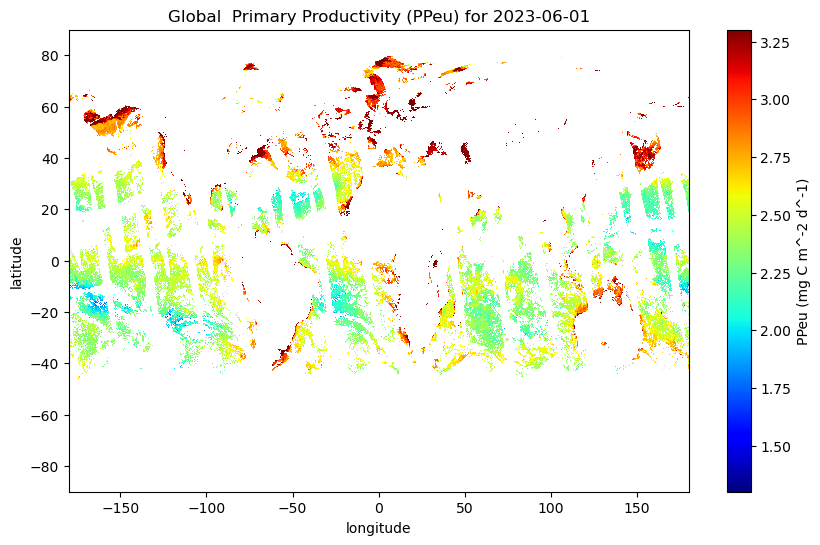

In [15]:
plot_PPeu(
    lon_grid,
    lat_grid,
    PPeu,
    title=f"Global  Primary Productivity (PPeu) for {(current_date - timedelta(days=1)).strftime('%Y-%m-%d')}",
)

## Plot SST

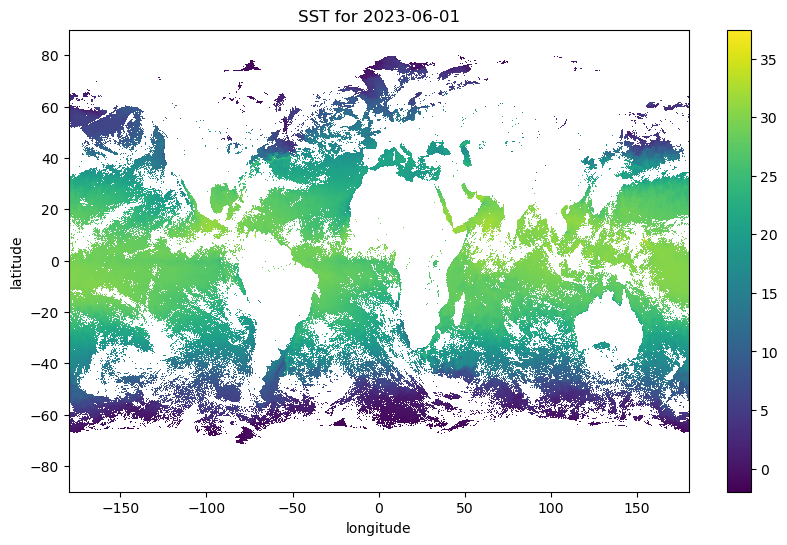

In [16]:
plot_globe(
    lon_grid,
    lat_grid,
    sst,
    title=f"SST for {(current_date - timedelta(days=1)).strftime('%Y-%m-%d')}",
)

## Verify $P_{opt}^b$
### Plotting $P_{opt}^b$ as a function of SST

The plot should show a smooth curve reflecting how productivity peaks within a specific SST range (~20 degrees Celisus).

<function matplotlib.pyplot.show(close=None, block=None)>

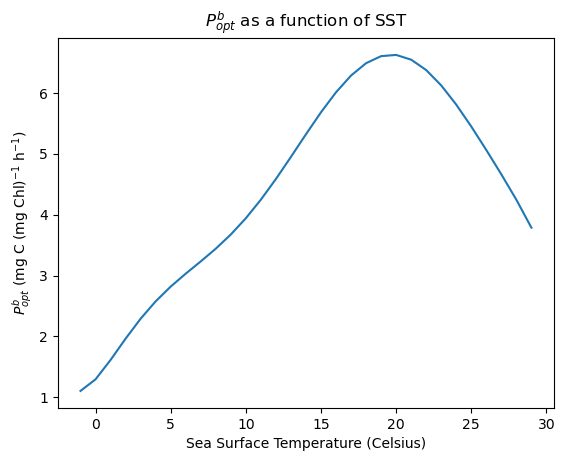

In [17]:
plt.plot(sst_list, PbOpt_plot)
plt.title("$P_{opt}^b$ as a function of SST")
plt.xlabel("Sea Surface Temperature (Celsius)")
plt.ylabel("$P_{opt}^b$ (mg C (mg Chl)$^{-1}$ h$^{-1}$)")
plt.show

## Plot CHL

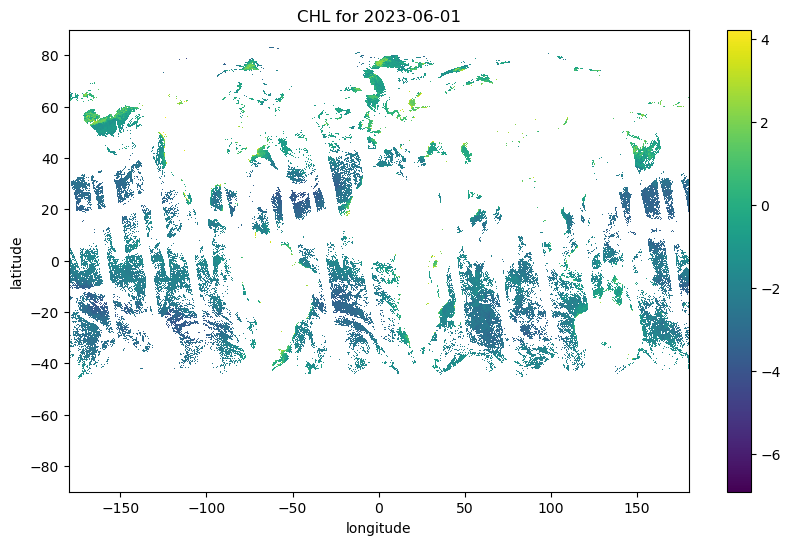

In [18]:
plot_globe(
    lon_grid,
    lat_grid,
    np.log(chl),
    title=f"CHL for {(current_date - timedelta(days=1)).strftime('%Y-%m-%d')}",
)

## Plot PAR

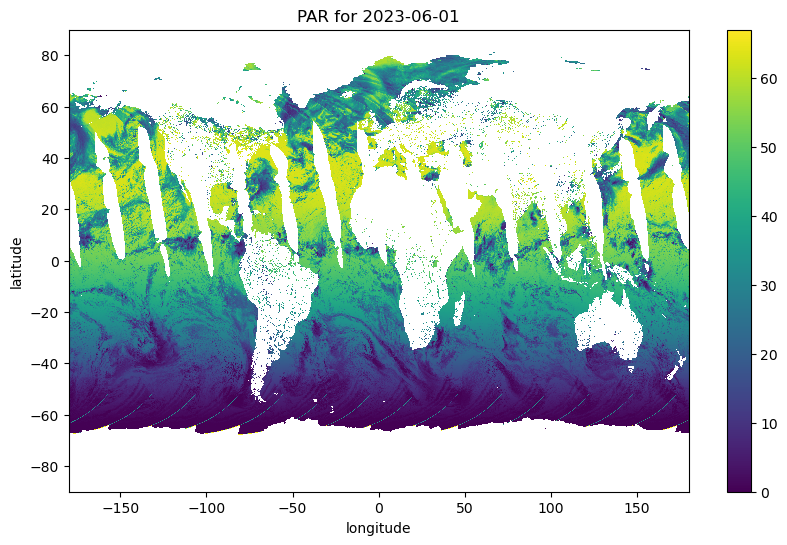

In [19]:
plot_globe(
    lon_grid,
    lat_grid,
    par,
    title=f"PAR for {(current_date - timedelta(days=1)).strftime('%Y-%m-%d')}",
)